<a href="https://colab.research.google.com/github/mastersigat/GeoPandas/blob/main/S%C3%A9ance1_IntroductionGeopandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Séance 1 / Manipulation et représentation de données spatiales avec GeoPandas** 🌐
GeoPandas est une librairie open source pour faciliter le travail avec des données géospatiales en python. GeoPandas étend les types de données utilisés par les pandas pour permettre des opérations spatiales sur des types géométriques. Les opérations géométriques sont effectuées par shapely. Geopandas dépend en outre de fiona pour l'accès aux fichiers et de matplotlib pour le traçage.

https://geopandas.org/en/stable/index.html



#Configuration de l'environnement de travail 🧰

In [ ]:
#Initialisation de l'environnement avec geopandas
!apt update
!apt install gdal-bin python-gdal python3-gdal
!apt install python3-rtree
! pip install geopandas
! pip install matplotlib
!pip install contextily
!pip install pygeos
!pip install mapclassify
!pip install folium
!pip install matplotlib_scalebar

In [3]:
#Importation des librairies nécessaires

import pandas as pd #Gestion de données
import matplotlib.pyplot as plt #Visualisation de données
import seaborn # Visualisation de données avancée
import geopandas as gpd #Gestion données spatiales
import contextily as ctx #Fonds de carte
import numpy as np #Manipulation de tableaux
import shapely #Manipulation de géométrie
import folium #Cartographie interactive
import mapclassify #Cartographie thématique
from matplotlib_scalebar.scalebar import ScaleBar #Echelle cartographique

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

# 🗺️ Couche des IRIS

### 📥 Importer et préparer la couche IRIS
Documentation import données SIG : https://geopandas.org/en/stable/docs/reference/api/geopandas.read_file.html

In [ ]:
#Téléchargement des datas depuis le site opendata de Paris

!wget -O IRIS.geojson https://data.iledefrance.fr/explore/dataset/iris/download/?format=geojson&refine.dep=75&timezone=Europe/Berlin&lang=fr

,typ_iris,insee_com,code_iris,nom_iris,dep,geo_point_2d,id,iris,nom_com,geometry
0,A,93063,930630101,Bas Pays,93,"[48.89469105740408, 2.4339936032886005]",IRIS____0000000930630101,0101,Romainville,"POLYGON ((2.42661 48.89287, 2.42773 48.8959, 2..."
1,H,78644,786440101,Bois de l'Étang,78,"[48.75889363749545, 1.9646913934927093]",IRIS____0000000786440101,0101,La Verrière,"POLYGON ((1.96799 48.75603, 1.9678 48.756, 1.9..."
2,H,77053,770530101,Leclerc-Centre Ouest,77,"[48.69188538671072, 2.5913435285805986]",IRIS____0000000770530101,0101,Brie-Comte-Robert,"POLYGON ((2.58565 48.67894, 2.58524 48.67914, ..."
3,H,78642,786420101,Les Hauts de Verneuil,78,"[48.97382146811184, 1.9620723275040297]",IRIS____0000000786420101,0101,Verneuil-sur-Seine,"POLYGON ((1.97667 48.97476, 1.97554 48.97391, ..."
4,H,94019,940190102,Centre Ville Château,94,"[48.79027005018674, 2.527242899604056]",IRIS____0000000940190102,0102,Chennevières-sur-Marne,"POLYGON ((2.5326 48.79205, 2.53196 48.79049, 2..."


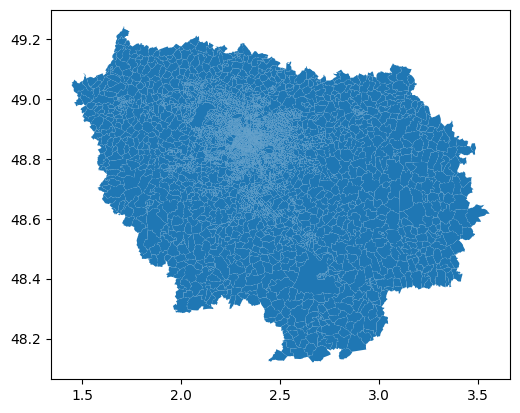

In [6]:
#Importer le couche des IRIS
IRIS= gpd.read_file("IRIS.geojson", encoding='utf-8')
IRIS.plot()
IRIS.head(5)

<Axes: >

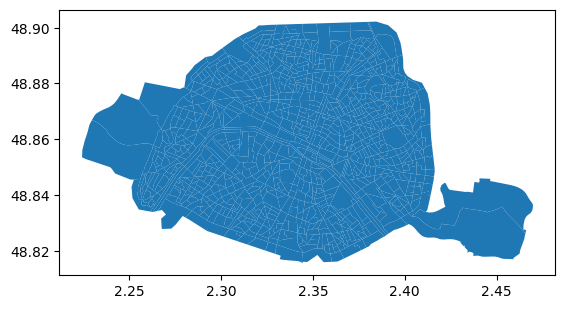

In [7]:
#Garder uniquement les IRIS de Paris
IRISPARIS = IRIS[(IRIS["dep"] == "75")]
IRISPARIS.plot()

### 🔎 Explorer la couche

In [8]:
# Afficher le nombre d'entités d'une couche

len(IRISPARIS)

992

In [9]:
# Afficher le nombre d'entités d'une couche avec du texte

print(str(len(IRISPARIS)) + " IRIS dans la zone d'étude")

992 IRIS dans la zone d'étude


In [10]:
#Checker les types des champs de la couche IRIS

IRIS.dtypes

,0
typ_iris,object
insee_com,int32
code_iris,object
nom_iris,object
dep,object
geo_point_2d,object
id,object
iris,object
nom_com,object
geometry,geometry


### 📚 Préparer la couche

In [11]:
#Garder que les colonnes utiles

IRISPARIS = IRISPARIS[["nom_iris", "insee_com", "code_iris", "geometry"]]
IRISPARIS.head(5)

,nom_iris,insee_com,code_iris,geometry
35,Porte Saint-Denis 1,75110,751103801,"POLYGON ((2.3573 48.87492, 2.35715 48.87469, 2..."
36,Folie Méricourt 13,75111,751114113,"POLYGON ((2.3729 48.87057, 2.37466 48.87125, 2..."
37,Necker 15,75115,751155815,"POLYGON ((2.31319 48.84217, 2.31259 48.84293, ..."
38,Muette 21,75116,751166221,"POLYGON ((2.28659 48.86206, 2.2868 48.86234, 2..."
39,Ternes 7,75117,751176507,"POLYGON ((2.28996 48.88085, 2.28839 48.87999, ..."


In [12]:
#Changer le type d'une colonne
                                #str
                                #int
                                #float


IRISPARIS['insee_com'] = IRISPARIS['insee_com'].astype(str)

In [13]:
# Renommer les noms des champs

IRISPARIS.rename(columns={'nom_iris': 'nom', 'code_iris': 'iris_code','insee_com': 'code_insee'}, inplace=True)
IRISPARIS.head()

,nom,code_insee,iris_code,geometry
35,Porte Saint-Denis 1,75110,751103801,"POLYGON ((2.3573 48.87492, 2.35715 48.87469, 2..."
36,Folie Méricourt 13,75111,751114113,"POLYGON ((2.3729 48.87057, 2.37466 48.87125, 2..."
37,Necker 15,75115,751155815,"POLYGON ((2.31319 48.84217, 2.31259 48.84293, ..."
38,Muette 21,75116,751166221,"POLYGON ((2.28659 48.86206, 2.2868 48.86234, 2..."
39,Ternes 7,75117,751176507,"POLYGON ((2.28996 48.88085, 2.28839 48.87999, ..."


In [14]:
# Concaténer des champs

IRISPARIS["concat"] = IRISPARIS["code_insee"] + " - " + IRISPARIS["nom"]
IRISPARIS.head()

,nom,code_insee,iris_code,geometry,concat
35,Porte Saint-Denis 1,75110,751103801,"POLYGON ((2.3573 48.87492, 2.35715 48.87469, 2...",75110 - Porte Saint-Denis 1
36,Folie Méricourt 13,75111,751114113,"POLYGON ((2.3729 48.87057, 2.37466 48.87125, 2...",75111 - Folie Méricourt 13
37,Necker 15,75115,751155815,"POLYGON ((2.31319 48.84217, 2.31259 48.84293, ...",75115 - Necker 15
38,Muette 21,75116,751166221,"POLYGON ((2.28659 48.86206, 2.2868 48.86234, 2...",75116 - Muette 21
39,Ternes 7,75117,751176507,"POLYGON ((2.28996 48.88085, 2.28839 48.87999, ...",75117 - Ternes 7


In [15]:
#Séparer une colonne (substr)

IRISPARIS['ardt'] = IRISPARIS['code_insee'].str[-2:]
IRISPARIS.head()

,nom,code_insee,iris_code,geometry,concat,ardt
35,Porte Saint-Denis 1,75110,751103801,"POLYGON ((2.3573 48.87492, 2.35715 48.87469, 2...",75110 - Porte Saint-Denis 1,10
36,Folie Méricourt 13,75111,751114113,"POLYGON ((2.3729 48.87057, 2.37466 48.87125, 2...",75111 - Folie Méricourt 13,11
37,Necker 15,75115,751155815,"POLYGON ((2.31319 48.84217, 2.31259 48.84293, ...",75115 - Necker 15,15
38,Muette 21,75116,751166221,"POLYGON ((2.28659 48.86206, 2.2868 48.86234, 2...",75116 - Muette 21,16
39,Ternes 7,75117,751176507,"POLYGON ((2.28996 48.88085, 2.28839 48.87999, ...",75117 - Ternes 7,17


In [60]:
# Afficher les modalitées d'une colonne

IRISPARIS["ardt"].unique().tolist()

['10',
 '11',
 '15',
 '16',
 '17',
 '18',
 '19',
 '20',
 '01',
 '07',
 '14',
 '03',
 '05',
 '06',
 '13',
 '12',
 '09',
 '08',
 '02',
 '04']

In [16]:
# Supprimer une colonne

IRISPARIS.drop(columns=['concat'], inplace=True)
IRISPARIS.head()

,nom,code_insee,iris_code,geometry,ardt
35,Porte Saint-Denis 1,75110,751103801,"POLYGON ((2.3573 48.87492, 2.35715 48.87469, 2...",10
36,Folie Méricourt 13,75111,751114113,"POLYGON ((2.3729 48.87057, 2.37466 48.87125, 2...",11
37,Necker 15,75115,751155815,"POLYGON ((2.31319 48.84217, 2.31259 48.84293, ...",15
38,Muette 21,75116,751166221,"POLYGON ((2.28659 48.86206, 2.2868 48.86234, 2...",16
39,Ternes 7,75117,751176507,"POLYGON ((2.28996 48.88085, 2.28839 48.87999, ...",17


### 🔽 Faire des filtres attributaires

<Axes: >

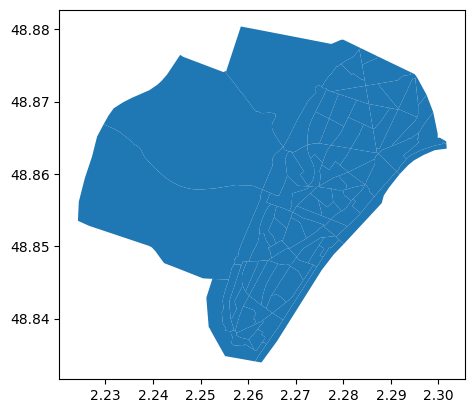

In [17]:
# Sélectionner selon une modalité d'une colonne

IRIS16eme = IRISPARIS[(IRISPARIS["ardt"] == '16')]
IRIS16eme.plot()

<Axes: >

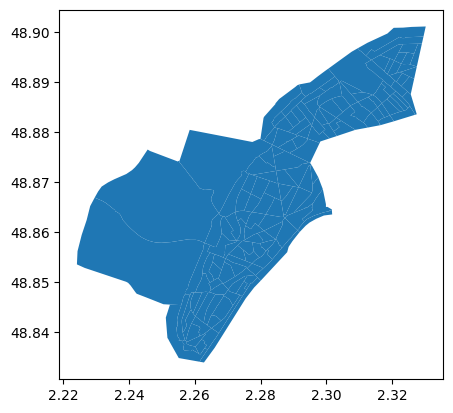

In [18]:
# Sélectionner selon deux modalité d'une variable (OR)

IRIS16et17eme = IRISPARIS[(IRISPARIS["ardt"] == '16') | (IRISPARIS["ardt"] == '17')]
IRIS16et17eme.plot()

<Axes: >

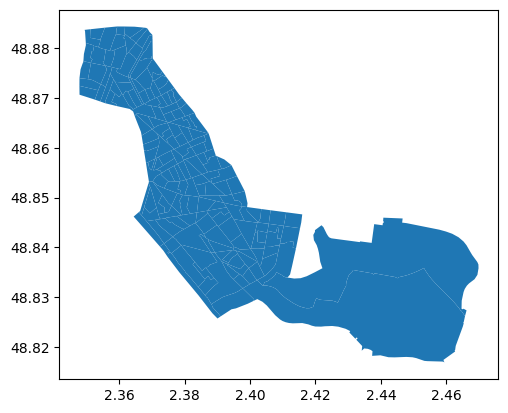

In [19]:
# Sélectionner selon un ensemble de mocalité (IN)

IRIS101112eme = IRISPARIS[IRISPARIS["ardt"].isin(['10', '11', '12'])]
IRIS101112eme.plot()

<Axes: >

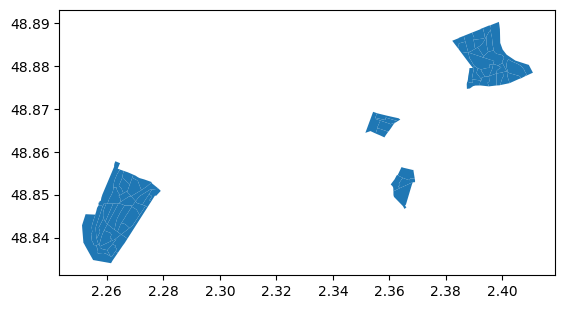

In [20]:
# Selection sur une chaine de charactères (LIKE)

IRIScommentparA = IRISPARIS[IRISPARIS["nom"].str.startswith('A')]
IRIScommentparA.plot()

<Axes: >

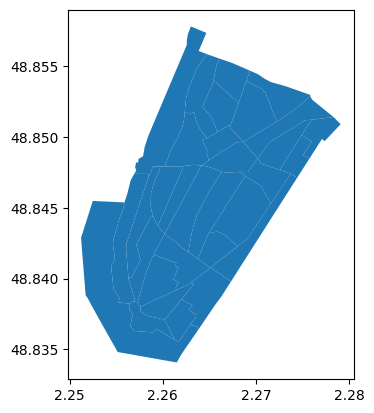

In [21]:
# Sélectionner selon les modalités de deux variables (AND)

IRIS16quicommencepar1 = IRISPARIS[(IRISPARIS["ardt"] == "16") & (IRISPARIS['nom'].str.startswith("A"))]
IRIS16quicommencepar1.plot()

<Axes: >

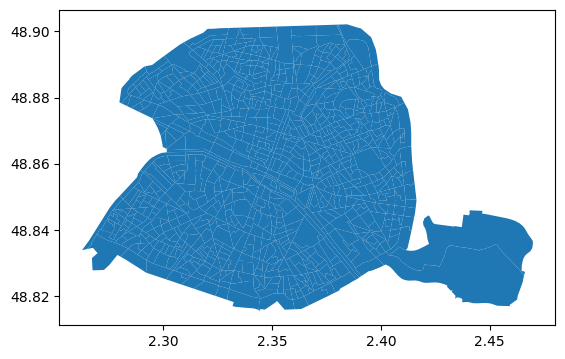

In [22]:
# Sélectioner toute les modalités sauf une (NOT)

IRISSANS16eme = IRISPARIS[~(IRISPARIS["ardt"] == '16')]
IRISSANS16eme.plot()

### 🗺️ Premiers pas cartographiques

/tmp/ipykernel_186/2101010020.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  IRISPARIScentro.geometry = IRISPARIScentro['geometry'].centroid


,nom,code_insee,iris_code,geometry,ardt
35,Porte Saint-Denis 1,75110,751103801,POINT (2.3562 48.87443),10
36,Folie Méricourt 13,75111,751114113,POINT (2.37464 48.86984),11
37,Necker 15,75115,751155815,POINT (2.315 48.84295),15
38,Muette 21,75116,751166221,POINT (2.28762 48.85981),16
39,Ternes 7,75117,751176507,POINT (2.28728 48.88133),17


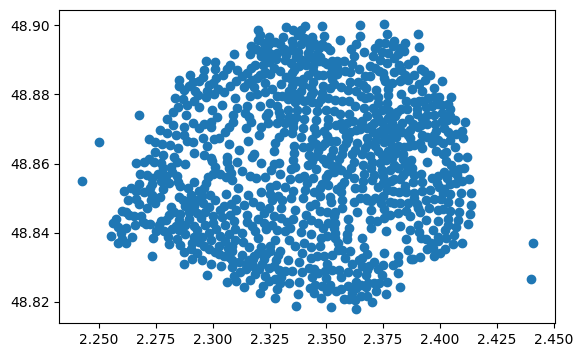

In [23]:
#Passer les polygones en centroides (création d'une nouvelle une couche)

IRISPARIScentro = IRISPARIS.copy()
IRISPARIScentro.geometry = IRISPARIScentro['geometry'].centroid
IRISPARIScentro.plot()
IRISPARIScentro.head(5)

<Axes: >

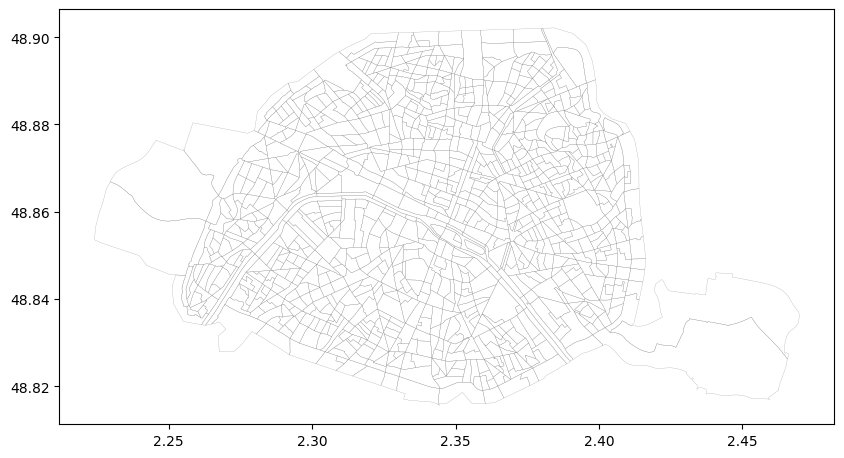

In [24]:
#Cartographier les IRIS en mode contours

IRISPARIS.boundary.plot(figsize=(10,10), linewidth=0.15, color = 'grey')

<Axes: >

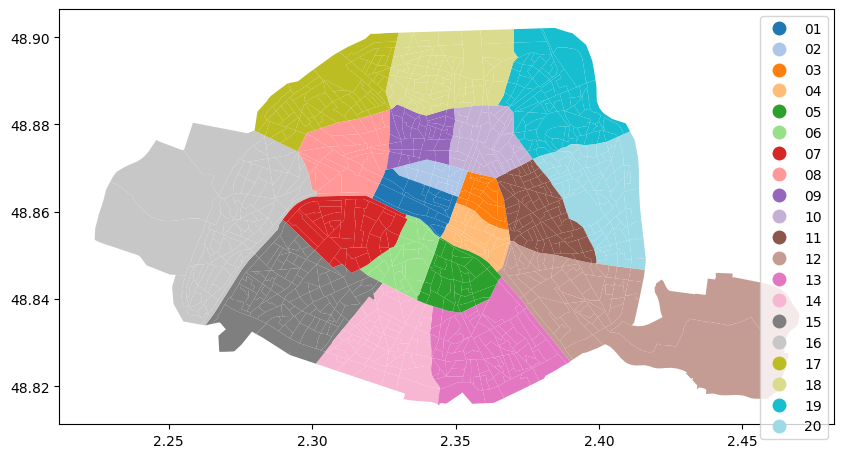

In [25]:
#Cartographier les IRIS en fonction de l'arrondissement

IRISPARIS.plot(column = "ardt", linewidth=0.5, figsize=(10,10), cmap='tab20', legend=True)

#🚲 Couche des Vélibs

## 📥 Importer et préparer la couche

In [ ]:
#Importer la couche des velibs
#URL du dataset : https://opendata.paris.fr/explore/dataset/velib-disponibilite-en-temps-reel/


,stationcode,name,is_installed,capacity,numdocksavailable,numbikesavailable,mechanical,ebike,is_renting,is_returning,duedate,nom_arrondissement_communes,code_insee_commune,station_opening_hours,geometry
0,32304,Charcot - Benfleet,OUI,28,25,3,0,3,OUI,OUI,2026-03-03 09:06:50+00:00,Romainville,93063,None,POINT (2.44052 48.87837)
1,16107,Benjamin Godard - Victor Hugo,OUI,35,14,21,18,3,OUI,OUI,2026-03-03 09:10:01+00:00,Paris,75056,None,POINT (2.27572 48.86598)
2,9020,Toudouze - Clauzel,OUI,21,15,5,4,1,OUI,OUI,2026-03-03 09:11:08+00:00,Paris,75056,None,POINT (2.33736 48.8793)
3,40001,Hôpital Mondor,OUI,28,15,13,5,8,OUI,OUI,2026-03-03 09:08:29+00:00,Créteil,94028,None,POINT (2.45375 48.79892)
4,14014,Jourdan - Stade Charléty,OUI,60,44,16,2,14,OUI,OUI,2026-03-03 09:05:59+00:00,Paris,75056,None,POINT (2.34334 48.81943)


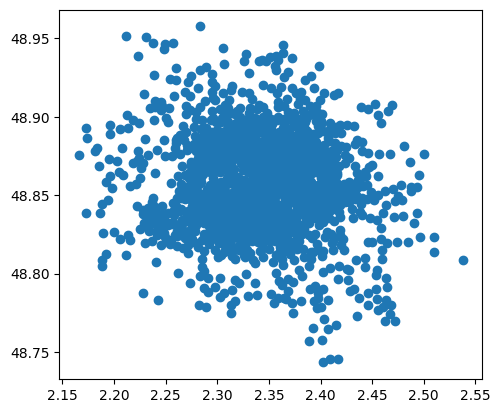

In [27]:
#Importer le couche des Velibs

<Axes: >

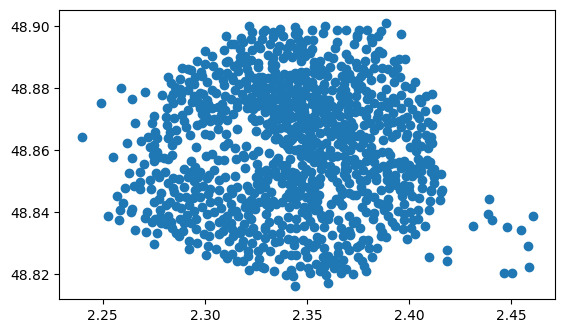

In [28]:
#Ne garder que les stations de Velibs de la ville de Paris (sélection par attribut)

In [29]:
# Afficher le nombre de stations vélib dans le jeux de données


996

In [30]:
# Afficher le nombre de stations vélib dans le jeux de données avec du texe


996 stations de vélibs dans la zone d'étude


In [31]:
# Ne garder que les champs intéressants et les renommer

VelibParis = VelibParis[["name", "stationcode", "ebike", "mechanical", "numbikesavailable", "numdocksavailable", "capacity", "geometry"]]
VelibParis = VelibParis.rename(columns={'name': 'Nom', 'stationcode':'Code', 'ebike': 'Veloselectriques', 'ebike': 'Veloselectriques', 'mechanical': 'Velosmecaniques', 'numbikesavailable': 'Velosdispo', 'numdocksavailable': 'Soclesdispo', 'capacity': 'Capacite'})
VelibParis.head()

,Nom,Code,Veloselectriques,Velosmecaniques,Velosdispo,Soclesdispo,Capacite,geometry
1,Benjamin Godard - Victor Hugo,16107,3,18,21,14,35,POINT (2.27572 48.86598)
2,Toudouze - Clauzel,9020,1,4,5,15,21,POINT (2.33736 48.8793)
4,Jourdan - Stade Charléty,14014,14,2,16,44,60,POINT (2.34334 48.81943)
5,Cassini - Denfert-Rochereau,14111,13,7,20,5,25,POINT (2.33604 48.83753)
7,Charonne - Robert et Sonia Delaunay,11104,1,1,2,18,20,POINT (2.39257 48.85591)


## 📚 Ajouter des nouvelles colonnes

In [32]:
#Calculer une colonne capacité totale des stations (nouvelle colonne)

VelibParis['Capacite'] = VelibParis['Velosdispo'] + VelibParis['Soclesdispo']
VelibParis.head()

,Nom,Code,Veloselectriques,Velosmecaniques,Velosdispo,Soclesdispo,Capacite,geometry
1,Benjamin Godard - Victor Hugo,16107,3,18,21,14,35,POINT (2.27572 48.86598)
2,Toudouze - Clauzel,9020,1,4,5,15,20,POINT (2.33736 48.8793)
4,Jourdan - Stade Charléty,14014,14,2,16,44,60,POINT (2.34334 48.81943)
5,Cassini - Denfert-Rochereau,14111,13,7,20,5,25,POINT (2.33604 48.83753)
7,Charonne - Robert et Sonia Delaunay,11104,1,1,2,18,20,POINT (2.39257 48.85591)


In [33]:
#Calculer la proportion de vélos electrique par station (nouvelle colonne)


,Nom,Code,Veloselectriques,Velosmecaniques,Velosdispo,Soclesdispo,Capacite,geometry,propelec
1,Benjamin Godard - Victor Hugo,16107,3,18,21,14,35,POINT (2.27572 48.86598),14.285714
2,Toudouze - Clauzel,9020,1,4,5,15,20,POINT (2.33736 48.8793),20.000000
4,Jourdan - Stade Charléty,14014,14,2,16,44,60,POINT (2.34334 48.81943),87.500000
5,Cassini - Denfert-Rochereau,14111,13,7,20,5,25,POINT (2.33604 48.83753),65.000000
7,Charonne - Robert et Sonia Delaunay,11104,1,1,2,18,20,POINT (2.39257 48.85591),50.000000


In [34]:
# Ajouter une colonne avec le tx de disponibilité de chaque stations


,Nom,Code,Veloselectriques,Velosmecaniques,Velosdispo,Soclesdispo,Capacite,geometry,propelec,Txsocledispo
1,Benjamin Godard - Victor Hugo,16107,3,18,21,14,35,POINT (2.27572 48.86598),14.285714,40.000000
2,Toudouze - Clauzel,9020,1,4,5,15,20,POINT (2.33736 48.8793),20.000000,75.000000
4,Jourdan - Stade Charléty,14014,14,2,16,44,60,POINT (2.34334 48.81943),87.500000,73.333333
5,Cassini - Denfert-Rochereau,14111,13,7,20,5,25,POINT (2.33604 48.83753),65.000000,20.000000
7,Charonne - Robert et Sonia Delaunay,11104,1,1,2,18,20,POINT (2.39257 48.85591),50.000000,90.000000


In [36]:
# Ajouter une colonne avec le tx d'occupation de chaque stations


,Nom,Code,Veloselectriques,Velosmecaniques,Velosdispo,Soclesdispo,Capacite,geometry,propelec,Txsocledispo,Txvelodispo
1,Benjamin Godard - Victor Hugo,16107,3,18,21,14,35,POINT (2.27572 48.86598),14.285714,40.000000,60.000000
2,Toudouze - Clauzel,9020,1,4,5,15,20,POINT (2.33736 48.8793),20.000000,75.000000,25.000000
4,Jourdan - Stade Charléty,14014,14,2,16,44,60,POINT (2.34334 48.81943),87.500000,73.333333,26.666667
5,Cassini - Denfert-Rochereau,14111,13,7,20,5,25,POINT (2.33604 48.83753),65.000000,20.000000,80.000000
7,Charonne - Robert et Sonia Delaunay,11104,1,1,2,18,20,POINT (2.39257 48.85591),50.000000,90.000000,10.000000


In [37]:
# Définir le type de station (emetrice ou réceptrice)

VelibParis.loc[VelibParis['Velosdispo'] <VelibParis['Soclesdispo'], 'Type'] = 'Emetrice'
VelibParis.loc[VelibParis['Velosdispo'] >=VelibParis['Soclesdispo'], 'Type'] = 'Receptrice'
VelibParis.head()

,Nom,Code,Veloselectriques,Velosmecaniques,Velosdispo,Soclesdispo,Capacite,geometry,propelec,Txsocledispo,Txvelodispo,Type
1,Benjamin Godard - Victor Hugo,16107,3,18,21,14,35,POINT (2.27572 48.86598),14.285714,40.000000,60.000000,Receptrice
2,Toudouze - Clauzel,9020,1,4,5,15,20,POINT (2.33736 48.8793),20.000000,75.000000,25.000000,Emetrice
4,Jourdan - Stade Charléty,14014,14,2,16,44,60,POINT (2.34334 48.81943),87.500000,73.333333,26.666667,Emetrice
5,Cassini - Denfert-Rochereau,14111,13,7,20,5,25,POINT (2.33604 48.83753),65.000000,20.000000,80.000000,Receptrice
7,Charonne - Robert et Sonia Delaunay,11104,1,1,2,18,20,POINT (2.39257 48.85591),50.000000,90.000000,10.000000,Emetrice


## ✅ Calculer des statistique basiques (descriptives)

In [38]:
#Calculer des statistiques basiques pour tous les champs de la couche des vélibs

VelibParis.describe()

,Veloselectriques,Velosmecaniques,Velosdispo,Soclesdispo,Capacite,propelec,Txsocledispo,Txvelodispo
count,996.000000,996.000000,996.000000,996.000000,996.000000,935.000000,991.000000,991.000000
mean,4.717871,8.689759,13.407631,19.589357,32.996988,49.391053,59.930058,40.069942
std,5.209358,11.065957,13.993197,15.146489,14.481004,32.953794,34.674369,34.674369
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,3.000000,8.000000,23.000000,21.428571,28.669276,9.175084
50%,3.000000,4.000000,8.000000,19.000000,31.000000,46.153846,73.333333,26.666667
75%,6.000000,13.000000,21.000000,29.000000,41.000000,75.000000,90.824916,71.330724
max,34.000000,64.000000,83.000000,200.000000,200.000000,100.000000,100.000000,100.000000


In [39]:
# Calculer le nombre de stations de vélibs

VelibParis["Code"].size

996

In [40]:
# Calculer la somme totale des capacités des stations

VelibParis["Capacite"].sum()

np.int64(32865)

In [41]:
# Calculer la moyenne des capacités par station

VelibParis["Capacite"].mean()

np.float64(32.99698795180723)

In [42]:
#Calculer le nombre total de vélibs, le nombre total vélibs électrique et le nombre total de vélibs mécaniques
A=VelibParis['Velosdispo'].sum()
B=VelibParis['Velosmecaniques'].sum()
C=VelibParis['Veloselectriques'].sum()

print(A, 'vélos disponibles  / ', B, 'vélos mécaniques  / ', C, 'vélos électriques')

13354 vélos disponibles  /  8655 vélos mécaniques  /  4699 vélos électriques


In [43]:
# Créer une fonction pour sortir un indicateur formaté et compréhensible

Txveloelec = (VelibParis['Veloselectriques'].sum())/ (VelibParis['Velosdispo'].sum()) *100
Txveloelec = round(Txveloelec,1)
print ("Taux de vélos électriques " + str(Txveloelec) + "%")

Taux de vélos électriques 35.2%


## 📊 Graphiques exploratoires

Text(0.5, 0, 'Nombre de socles')

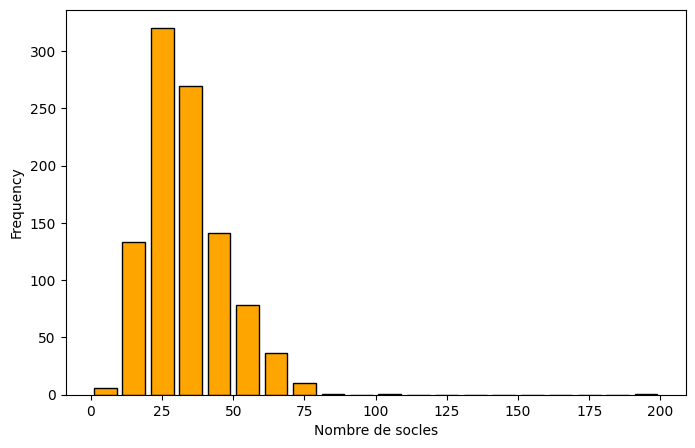

In [44]:
# Histogramme de distribution des capacités des stations

ax = VelibParis.plot.hist(y='Capacite', figsize=(8, 5), bins=20, rwidth=0.8, edgecolor='black', color='orange',legend=False)
ax.set_xlabel('Nombre de socles')

<Axes: xlabel='Capacite', ylabel='Veloselectriques'>

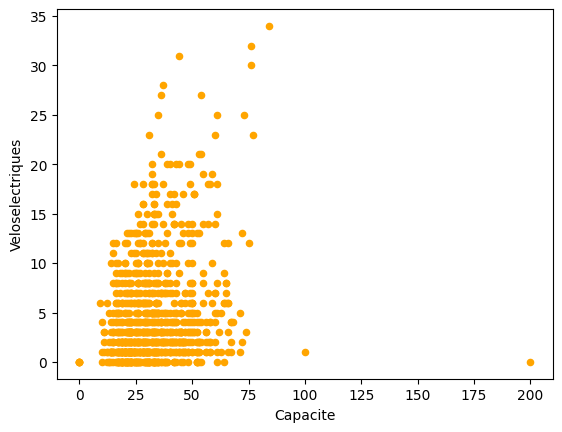

In [45]:
# Scatterplot

VelibParis.plot.scatter('Capacite', 'Veloselectriques', color= 'orange' )

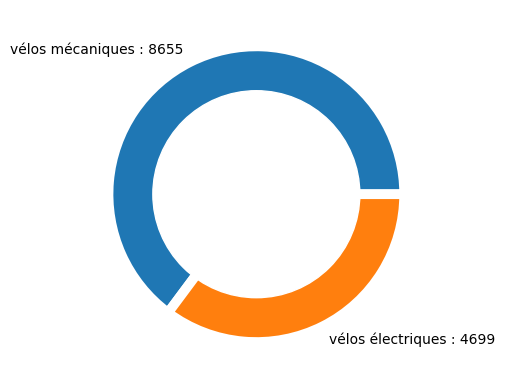

In [46]:
# Doughnut Chart

names = ['vélos mécaniques', 'vélos électriques']
size = [VelibParis['Velosmecaniques'].sum(), VelibParis['Veloselectriques'].sum()]

# Créer des labels combinant le nom et la valeur
labels = [f'{n} : {s}' for n, s in zip(names, size)]

# Créer le cercle central pour le donut
my_circle = plt.Circle((0,0), 0.7, color='white')

# Tracer le pie chart avec labels combinés
plt.pie(
    size,
    labels=labels,
    wedgeprops={'linewidth': 7, 'edgecolor': 'white'}
)

# Ajouter le cercle au centre
p = plt.gcf()
p.gca().add_artist(my_circle)

plt.show()

# 🌐 La couche des arrondissements (à importer via un fichier en local)

Télécharger le geosjon puis charger le dans l'environnement

https://opendata.paris.fr/explore/dataset/arrondissements/export/?disjunctive.c_ar&disjunctive.c_arinsee&disjunctive.l_ar

,n_sq_ar,c_ar,c_arinsee,l_ar,l_aroff,n_sq_co,surface,perimetre,geom_x_y,geometry
0,750000004,4,75104,4ème Ardt,Hôtel-de-Ville,750001537,1.600586e+06,5420.908434,"{'lon': 2.357629620324997, 'lat': 48.854341426...","POLYGON ((2.36851 48.85573, 2.369 48.85374, 2...."
1,750000005,5,75105,5ème Ardt,Panthéon,750001537,2.539375e+06,6239.195396,"{'lon': 2.3507146095752587, 'lat': 48.84444315...","POLYGON ((2.36443 48.84614, 2.36484 48.84584, ..."
2,750000010,10,75110,10ème Ardt,Entrepôt,750001537,2.891739e+06,6739.375055,"{'lon': 2.360728487847452, 'lat': 48.876130036...","POLYGON ((2.36469 48.88437, 2.36485 48.88436, ..."
3,750000018,18,75118,18ème Ardt,Buttes-Montmartre,750001537,5.996051e+06,9916.464176,"{'lon': 2.3481605195620396, 'lat': 48.89256926...","POLYGON ((2.3658 48.88554, 2.36469 48.88437, 2..."
4,750000003,3,75103,3ème Ardt,Temple,750001537,1.170883e+06,4519.263648,"{'lon': 2.360000985897692, 'lat': 48.862872380...","POLYGON ((2.36383 48.8675, 2.36389 48.86747, 2..."


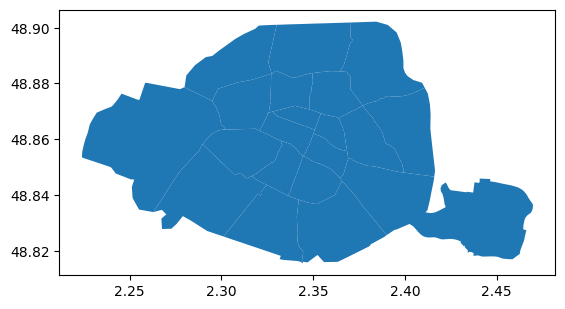

In [ ]:
#Importer le jeu de données dans l'espace de travail puis le convertir en gdf

Ardt= gpd.read_file("arrondissements.geojson", encoding='utf-8')
Ardt.plot()
Ardt.head()

# 🗺️ Cartographie thématique

* Couleurs de ColorBrewer > https://www.datanovia.com/en/wp-content/uploads/dn-tutorials/ggplot2/figures/101-rcolorbrewer-palette-rcolorbrewer-palettes-1.png

* Inverser palette de couleur : _r

* Documentation carto thématique : https://geopandas.org/en/stable/gallery/choropleths.html

## Cartographies de base

<Axes: >

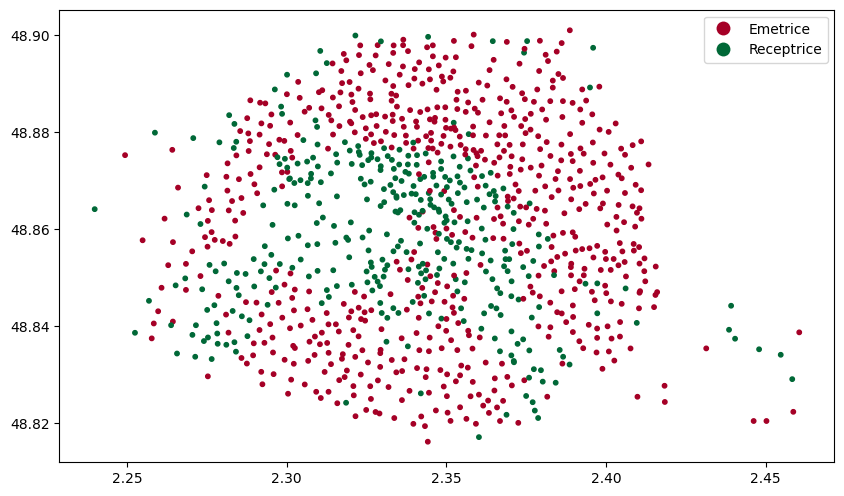

In [ ]:
#Cartographier le type de station (catégorisation)

VelibParis.plot(figsize=(10,10), alpha=1, column="Type", cmap='RdYlGn', categorical=True, markersize=10, legend=True)

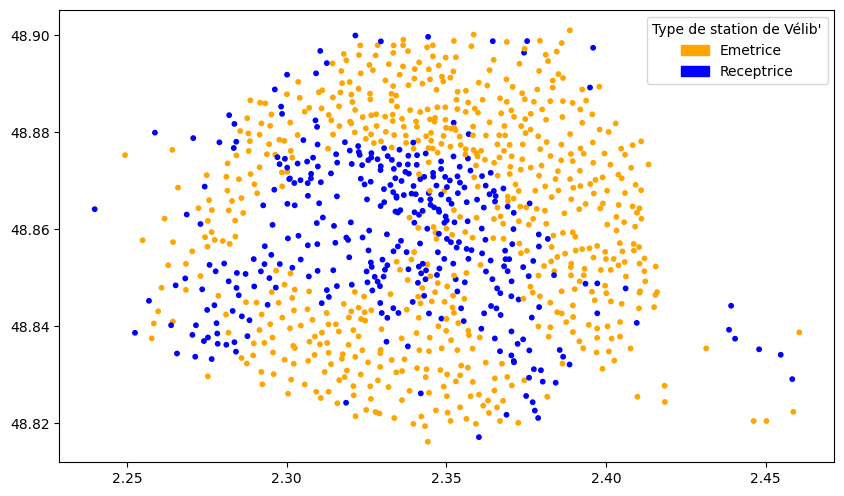

In [ ]:
#Cartographier le type de station (catégorisation avec couleurs personnalisées)

import matplotlib.patches as mpatches

# Mapping type → couleur
color_dict = {
    "Emetrice": "orange",
    "Receptrice": "blue"
}

# Colonne couleur
VelibParis['color'] = VelibParis['Type'].map(color_dict)

# Plot et récupération de l'axe
ax = VelibParis.plot(figsize=(10,10), color=VelibParis['color'], markersize=10, alpha=1)


# Légende manuelle attachée à l'axe
patches = [mpatches.Patch(color=color, label=label) for label, color in color_dict.items()]
ax.legend(handles=patches, title="Type de station de Vélib'")

plt.show()

<Axes: >

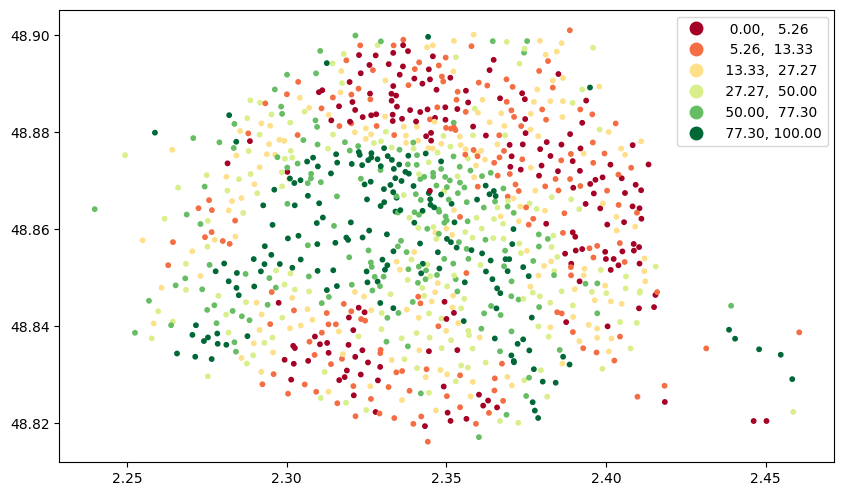

In [ ]:
#Cartographier le taux d'occupation par station (graduation de couleurs)

VelibParis.plot(figsize=(10,10), alpha=1, column="Txoccupation", cmap='RdYlGn', k = 6, scheme='quantiles', markersize=10, categorical=False, legend=True)

<Axes: >

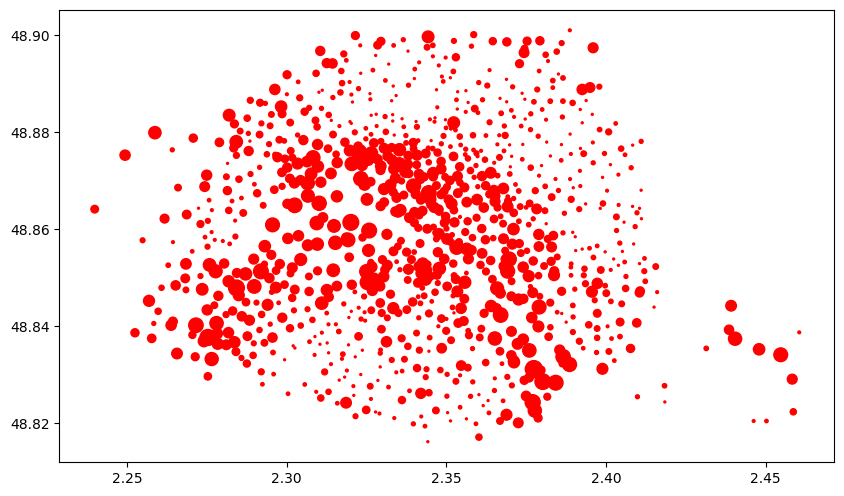

In [ ]:
#Cartographier le nombre de vélibs disponibles par station (variation de tailles)

VelibParis.plot(figsize=(10,10), markersize=VelibParis["Velosdispo"]*2,alpha=1, color = 'red', categorical=False, legend=True)

<Axes: >

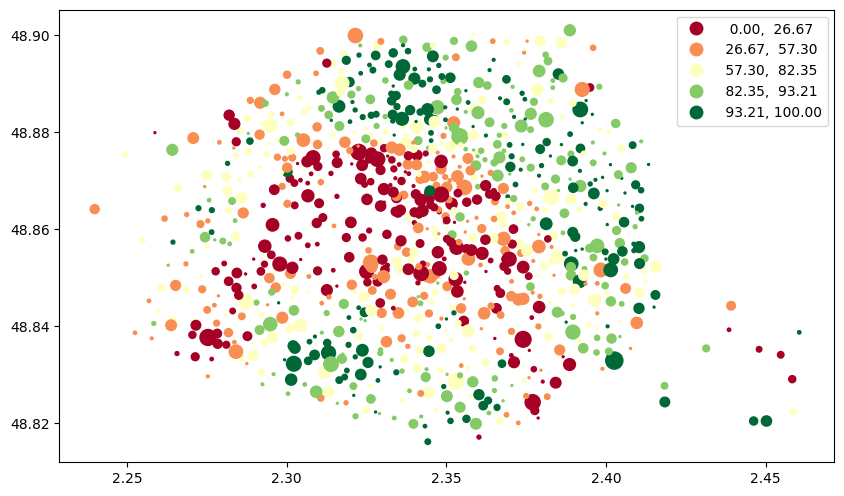

In [ ]:
#Cartographier le nombre de vélibs disponibles et le taux d'occupation par station (variation de tailles et de couleurs)

VelibParis.plot(figsize=(10,10), markersize=VelibParis["Velosdispo"]*2, alpha=1, column="Txdispo", cmap='RdYlGn',scheme='quantiles', categorical=False, legend=True)

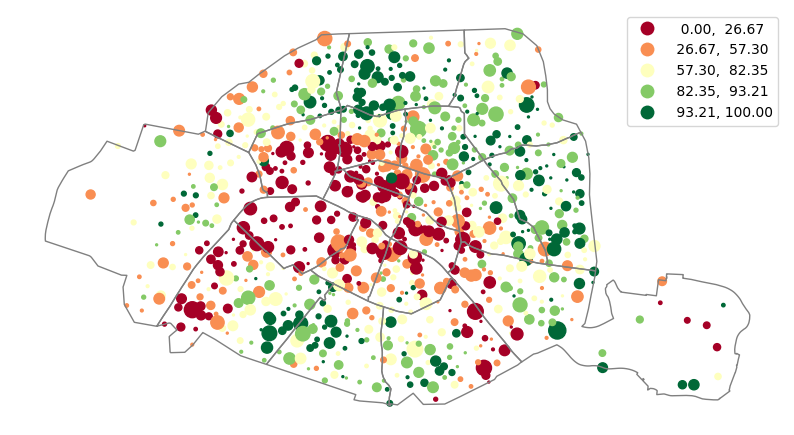

In [ ]:
#Cartographier le nombre de vélibs disponibles et le taux d'occupation par station (variation de tailles et de couleurs)


Carte1, ax = plt.subplots(figsize=(10,10))  # Configuration de la carte

VelibParis.plot(ax=ax, markersize=VelibParis["Velosdispo"]*2, alpha=1, column="Txdispo", cmap='RdYlGn',scheme='quantiles', categorical=False, legend=True, zorder= 2) # Appel couche Velibs
Ardt.boundary.plot(ax=ax, linewidth=1, color = 'grey') # Appel couche arrondissements
ax.axis("off") # On enlève les axes


plt.show() #Génération de la carte

## Habiller ses cartes (fond de carte, titre, échelles...)
https://contextily.readthedocs.io/en/latest/intro_guide.html

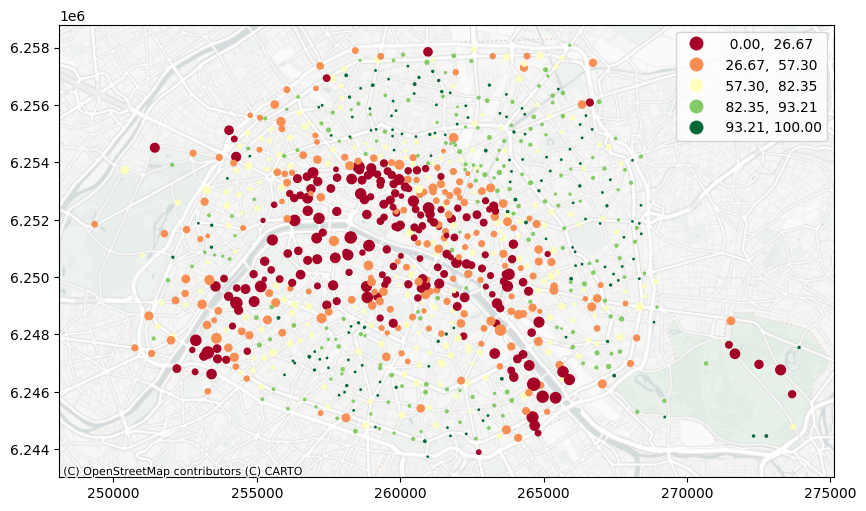

In [ ]:
#Cartographier le nombre de vélibs disponibles et le taux d'occupation par station avec un fond de carte CartoDB

ax = VelibParis.to_crs('EPSG:3857').plot(figsize=(10,10),markersize="Velosdispo",alpha=1, column="Txdispo", cmap='RdYlGn',scheme='quantiles', categorical=False, legend=True)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.PositronNoLabels)

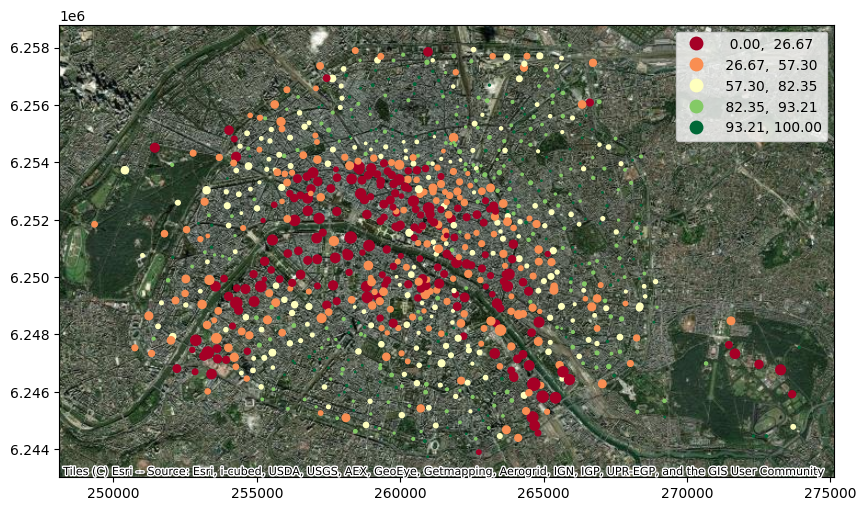

In [ ]:
#Cartographier le nombre de vélibs disponibles et le taux d'occupation par station avec un autre fond de carte

ax = VelibParis.to_crs('EPSG:3857').plot(figsize=(10,10),markersize="Velosdispo",alpha=1, column="Txdispo", cmap='RdYlGn',scheme='quantiles', categorical=False, legend=True)

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldImagery)

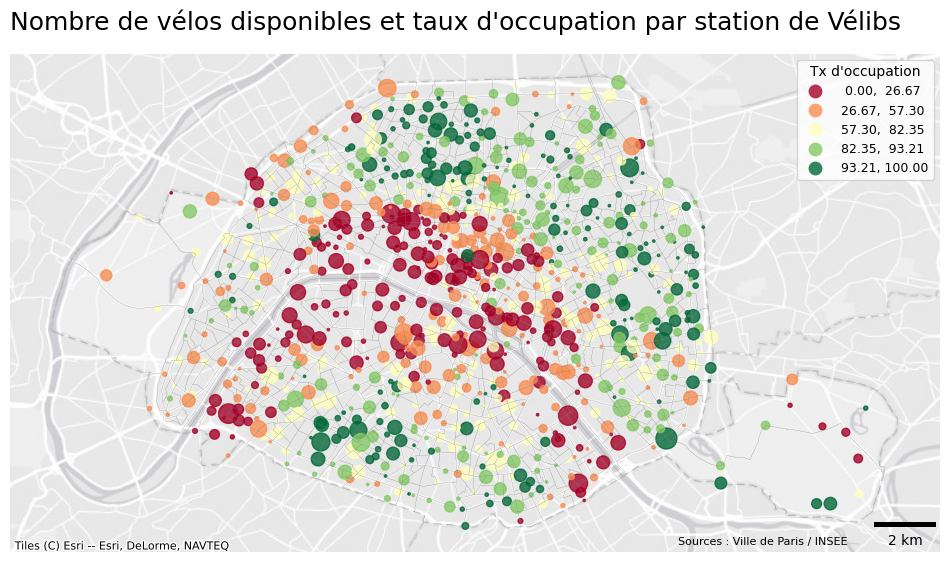

In [ ]:
#Faire une carte avec deux couches mise en forme

Carte1, ax = plt.subplots(figsize=(12,12))  # Configuration de la carte

IRISPARIS.boundary.to_crs('EPSG:3857').plot(ax=ax, linewidth=0.1, color = 'grey') # Configuration couche arrondissements
VelibParis.to_crs('EPSG:3857').plot(ax=ax, markersize=VelibParis['Velosdispo']*3,column="Txdispo", cmap='RdYlGn',scheme='quantiles', alpha=0.8,
                                    categorical=False,legend=True,
                                    legend_kwds={'title': "Tx d'occupation", 'loc': 'upper right', 'title_fontsize':10, 'fontsize':9}) # Configuration couche des vélibs

ctx.add_basemap(ax,source=ctx.providers.Esri.WorldGrayCanvas) # Configuration du fond de carte

# On enlève les axes
ax.axis("off")

# Ajout du titre de la carte
plt.title("Nombre de vélos disponibles et taux d'occupation par station de Vélibs", loc='left', fontsize=18)

#Ajout d'une échelle
ax.add_artist(ScaleBar(1, length_fraction=0.1, location = "lower right", box_alpha=0, color="black"))

# Ajout des sources
ax.text(0.90, 0.01, 'Sources : Ville de Paris / INSEE', verticalalignment='bottom', horizontalalignment='right',
        transform=ax.transAxes, color='black', fontsize=8)

plt.show() #Génération de la carte

In [ ]:
#Faire une carte finalisée avec trois couches (Vélibs, IRIS et Arrondissements)

In [ ]:
# Enreigistrer une carte en image

Carte1.savefig("Carte1.png")

# Ecrire un jeu de données spatiales 💾

Documentation export données spatiales : https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.to_file.html

In [ ]:
#Ecrire un geojson

VelibParis.to_file("Velibs.geojson", driver="GeoJSON")

In [ ]:
#Ecrire un gpk

IRISPARIS.to_file("Paris.gpkg", layer='IRIS', driver="GPKG")
VelibParis.to_file("Paris.gpkg", layer='VelibParis', driver="GPKG")
Ardt.to_file("Paris.gpkg", layer='Ardt', driver="GPKG")

# 🚗 🚲 Exercices sur les accidents

## Préparation de la couche

In [ ]:
#Téléchargement des datas depuis le site opendata de Paris

!wget -O Accidents.csv https://opendata.paris.fr/api/explore/v2.1/catalog/datasets/accidentologie0/exports/csv?lang=fr&timezone=Europe%2FBerlin&use_labels=true&delimiter=%3B

#Importer le couche des Accidents
Accidents= pd.read_csv("Accidents.csv", sep=';')
Accidents.head(5)

In [51]:
len(Accidents)

33638

In [52]:
#Séparer la columne des coordonnées géographiques

Accidents[['Latitude','Longitude']] = Accidents['coordonnes'].str.split(',', expand=True)
Accidents.head()

,annee,idusager,pv,victime_type,categorie,gravite,age,sexe_victime,milieu,adresse,...,nom_arrondissement,arronco,arrondgeo,adresse_1,adresse_2,coordonnes,iris,aondissement,Latitude,Longitude
0,2024-08-04,9370825,2337,EDP-m,Conducteur,Blessé léger,29.0,Masculin,En-Agg,RUE REAUMUR,...,NaN,75102,"{""coordinates"": [[[[2.347918228, 48.870687845]...",RUE REAUMUR,RUE DUSSOUBS,"48.866795, 2.349411",Paris 2e Arrondissement,75102.0,48.866795,2.349411
1,2024-09-04,9380299,2379,Piéton,Piéton,Blessé léger,65.0,Masculin,En-Agg,AVENUE PARMENTIER,...,NaN,75111,"{""coordinates"": [[[[2.369123881, 48.853166231]...",Rue Abel Rabaud,Avenue Parmentier,"48.869346, 2.371636",Paris 11e Arrondissement,75111.0,48.869346,2.371636
2,2024-10-04,9370846,2407,Piéton,Piéton,Blessé léger,26.0,Feminin,En-Agg,PLACE FRANCOIS 1ER,...,NaN,75108,"{""coordinates"": [[[[2.301737288, 48.863496077]...",Rue Jean Goujon,PLACE FRANCOIS 1ER,"48.86614, 2.307569",Paris 8e Arrondissement,75108.0,48.86614,2.307569
3,2024-04-13,9372404,2501,2 Roues Motorisées,Conducteur,Blessé léger,35.0,Masculin,En-Agg,AVENUE DE LA PORTE DE MONTROUGE,...,NaN,75114,"{""coordinates"": [[[[2.336656992, 48.839671108]...",AVENUE DE LA PORTE DE MONTROUGE,Boulevard Brune,"48.823684, 2.323173",Paris 14e Arrondissement,75114.0,48.823684,2.323173
4,2024-04-13,9387739,2507,2 Roues Motorisées,Conducteur,Blessé léger,37.0,Masculin,En-Agg,QUAI FRANCOIS MITTERRAND,...,NaN,75101,"{""coordinates"": [[[[2.325888017, 48.869576524]...",PONT DU CARROUSEL,QUAI FRANCOIS MITTERRAND,"48.860181, 2.33338",Paris 1er Arrondissement,75101.0,48.860181,2.33338


In [53]:
Accidents = Accidents[["annee", "victime_type", "categorie", "gravite", "age", "sexe_victime", "arronco", "Latitude", "Longitude"]]
Accidents.rename(columns={'annee' : 'date', 'victime_type': 'type','sexe_victime': 'sexe', 'arronco': 'ardt'}, inplace=True)
Accidents.head(5)


,date,type,categorie,gravite,age,sexe,ardt,Latitude,Longitude
0,2024-08-04,EDP-m,Conducteur,Blessé léger,29.0,Masculin,75102,48.866795,2.349411
1,2024-09-04,Piéton,Piéton,Blessé léger,65.0,Masculin,75111,48.869346,2.371636
2,2024-10-04,Piéton,Piéton,Blessé léger,26.0,Feminin,75108,48.86614,2.307569
3,2024-04-13,2 Roues Motorisées,Conducteur,Blessé léger,35.0,Masculin,75114,48.823684,2.323173
4,2024-04-13,2 Roues Motorisées,Conducteur,Blessé léger,37.0,Masculin,75101,48.860181,2.33338


In [54]:
#Créer une colonne avec le numéro de l'arrondissement (SUBSTR)
Accidents['ardt'] = Accidents['ardt'].astype(str)
Accidents['ardt'] = Accidents['ardt'].str[-2:]
Accidents.head()

,date,type,categorie,gravite,age,sexe,ardt,Latitude,Longitude
0,2024-08-04,EDP-m,Conducteur,Blessé léger,29.0,Masculin,02,48.866795,2.349411
1,2024-09-04,Piéton,Piéton,Blessé léger,65.0,Masculin,11,48.869346,2.371636
2,2024-10-04,Piéton,Piéton,Blessé léger,26.0,Feminin,08,48.86614,2.307569
3,2024-04-13,2 Roues Motorisées,Conducteur,Blessé léger,35.0,Masculin,14,48.823684,2.323173
4,2024-04-13,2 Roues Motorisées,Conducteur,Blessé léger,37.0,Masculin,01,48.860181,2.33338


In [55]:
#Créer une colonne avec le numéro de l'arrondissement (SUBSTR)
Accidents['annee'] = Accidents['date'].str[:4]
Accidents.head()

,date,type,categorie,gravite,age,sexe,ardt,Latitude,Longitude,annee
0,2024-08-04,EDP-m,Conducteur,Blessé léger,29.0,Masculin,02,48.866795,2.349411,2024
1,2024-09-04,Piéton,Piéton,Blessé léger,65.0,Masculin,11,48.869346,2.371636,2024
2,2024-10-04,Piéton,Piéton,Blessé léger,26.0,Feminin,08,48.86614,2.307569,2024
3,2024-04-13,2 Roues Motorisées,Conducteur,Blessé léger,35.0,Masculin,14,48.823684,2.323173,2024
4,2024-04-13,2 Roues Motorisées,Conducteur,Blessé léger,37.0,Masculin,01,48.860181,2.33338,2024


<Axes: >

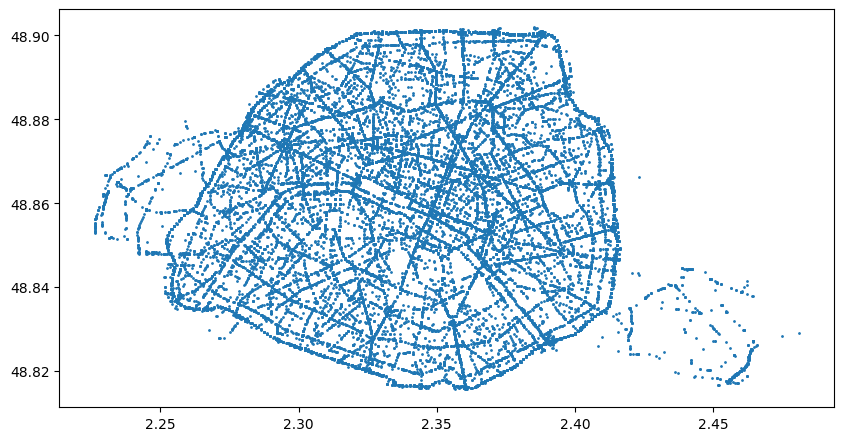

In [56]:
#Dataframe to GeoDataframe

Accidents = gpd.GeoDataFrame(Accidents, crs = 'epsg:4326', geometry=gpd.points_from_xy(Accidents.Longitude, Accidents.Latitude))
Accidents.plot(figsize=(10,12), markersize=1)

## Agrégations et graphiques

Documentation Matplotlib: https://matplotlib.org/stable/gallery/lines_bars_and_markers/index.html#

In [ ]:
# Regrouper les accidents part type avec comptage (GROUP BY)

typeaccidents = Accidents[["type", "annee"]].groupby("type").count()
typeaccidents = typeaccidents.sort_values("annee", ascending=False)
typeaccidents = typeaccidents.rename(columns={"annee": "nb"})
typeaccidents.head()

,nb
type,
2 Roues Motorisées,13078
Piéton,6870
Vélo,6026
4 Roues,5836
EDP-m,1827


In [ ]:
# Regrouper les accidents part type avec comptage (GROUP BY)

typeaccidents = Accidents[["type", "annee"]].groupby("type").count()
typeaccidents = typeaccidents.sort_values("annee", ascending=False)
typeaccidents = typeaccidents.reset_index()
typeaccidents = typeaccidents.rename(columns={"annee": "nb"})
typeaccidents.head()

,type,nb
0,2 Roues Motorisées,13078
1,Piéton,6870
2,Vélo,6026
3,4 Roues,5836
4,EDP-m,1827


Text(0, 0.5, "Nombre d'accidents")

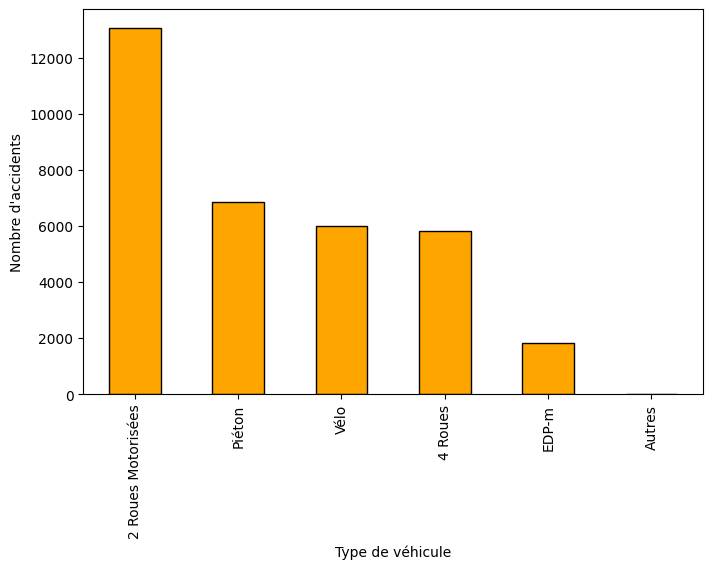

In [ ]:
# Graphique en colonne par type de véhicules concerné
ax = typeaccidents.plot.bar(
    x='type',
    y='nb',
    figsize=(8, 5),
    color='orange',
    edgecolor='black',
    legend=False
)

ax.set_xlabel("Type de véhicule")
ax.set_ylabel("Nombre d'accidents")

Text(0, 0.5, "Nombre d'accidents")

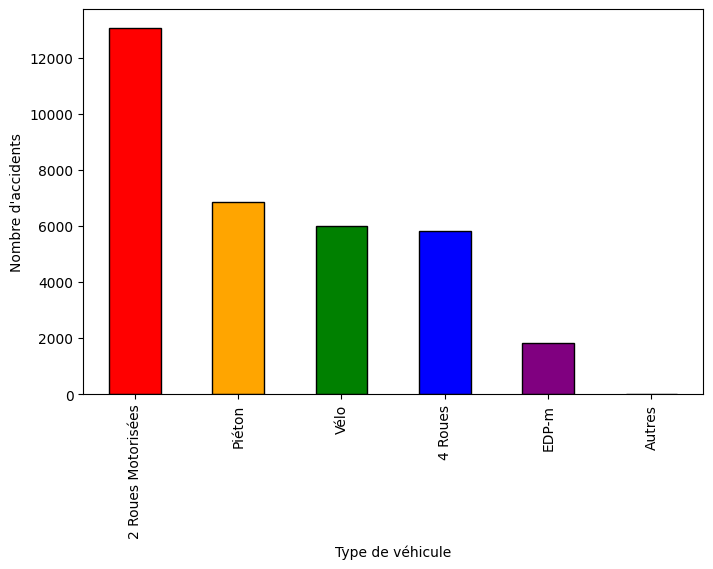

In [ ]:
# Graphique en colonne par type de véhicules concerné
ax = typeaccidents.plot.bar(
    x='type',
    y='nb',
    figsize=(8, 5),
    color=['red', 'orange', 'green', 'blue', 'purple'],
    edgecolor='black',
    legend=False
)

ax.set_xlabel("Type de véhicule")
ax.set_ylabel("Nombre d'accidents")

Text(0, 0.5, "Nombre d'accidents")

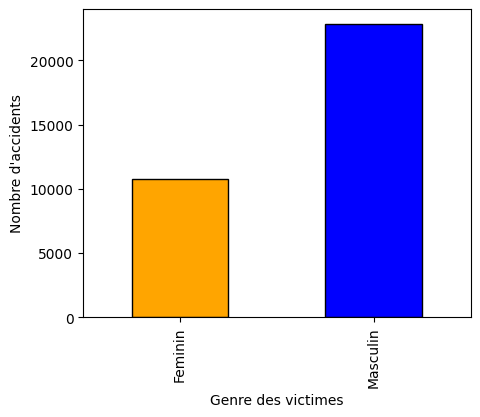

In [ ]:
# Graphique en colonne par genre des victimes

Text(0, 0.5, "Nombre d'accidents")

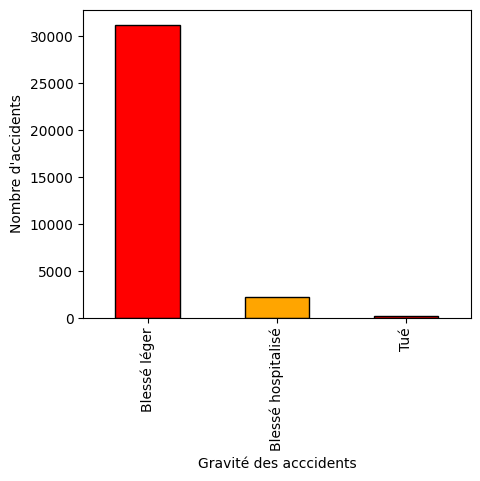

In [ ]:
# Graphique en colonne par genre des victimes

Text(0, 0.5, "Nombre d'accidents")

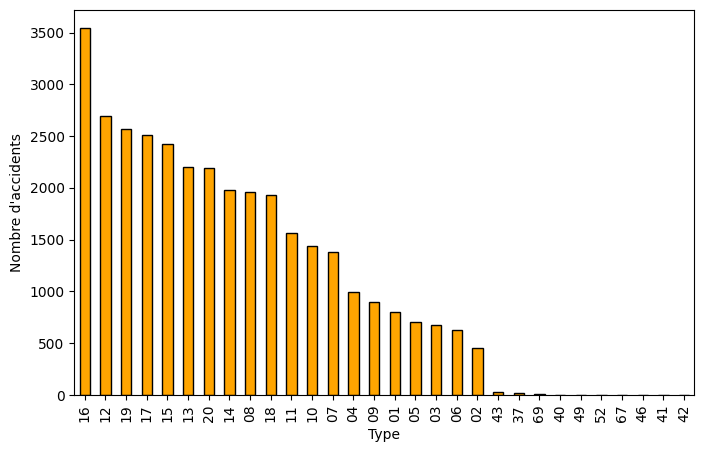

In [ ]:
# Histogramme de distribution du nombre d'accidents par arrondissement

Text(0, 0.5, "Nombre d'accidents")

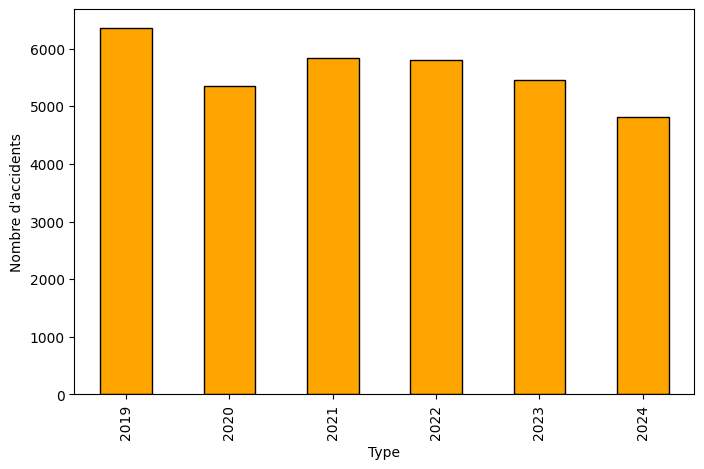

In [ ]:
# Histogramme de distribution du nombre d'accidents par année

## Ne travailler que sur certains type d'accidents

In [57]:
Accidents.head(5)

,date,type,categorie,gravite,age,sexe,ardt,Latitude,Longitude,annee,geometry
0,2024-08-04,EDP-m,Conducteur,Blessé léger,29.0,Masculin,02,48.866795,2.349411,2024,POINT (2.34941 48.8668)
1,2024-09-04,Piéton,Piéton,Blessé léger,65.0,Masculin,11,48.869346,2.371636,2024,POINT (2.37164 48.86935)
2,2024-10-04,Piéton,Piéton,Blessé léger,26.0,Feminin,08,48.86614,2.307569,2024,POINT (2.30757 48.86614)
3,2024-04-13,2 Roues Motorisées,Conducteur,Blessé léger,35.0,Masculin,14,48.823684,2.323173,2024,POINT (2.32317 48.82368)
4,2024-04-13,2 Roues Motorisées,Conducteur,Blessé léger,37.0,Masculin,01,48.860181,2.33338,2024,POINT (2.33338 48.86018)


In [59]:
# Afficher les modalitées d'une colonne

Accidents["type"].unique().tolist()

['EDP-m', 'Piéton', '2 Roues Motorisées', 'Vélo', '4 Roues', 'Autres']

In [64]:
# Reclassifier des modalités

Accidents["categorie"] = "Autre"

Accidents.loc[Accidents["type"].isin(["EDP-m", "Vélo"]), "categorie"] = "Non motorisé"
Accidents.loc[Accidents["type"].isin(["2 Roues Motorisées", "4 Roues"]), "categorie"] = "Motorisé"
Accidents.loc[Accidents["type"] == "Piéton", "categorie"] = "Piéton"
Accidents.head(5)

,date,type,categorie,gravite,age,sexe,ardt,Latitude,Longitude,annee,geometry
0,2024-08-04,EDP-m,Non motorisé,Blessé léger,29.0,Masculin,02,48.866795,2.349411,2024,POINT (2.34941 48.8668)
1,2024-09-04,Piéton,Piéton,Blessé léger,65.0,Masculin,11,48.869346,2.371636,2024,POINT (2.37164 48.86935)
2,2024-10-04,Piéton,Piéton,Blessé léger,26.0,Feminin,08,48.86614,2.307569,2024,POINT (2.30757 48.86614)
3,2024-04-13,2 Roues Motorisées,Motorisé,Blessé léger,35.0,Masculin,14,48.823684,2.323173,2024,POINT (2.32317 48.82368)
4,2024-04-13,2 Roues Motorisées,Motorisé,Blessé léger,37.0,Masculin,01,48.860181,2.33338,2024,POINT (2.33338 48.86018)


In [65]:
# Afficher les modalitées d'une colonne

Accidents["categorie"].unique().tolist()

['Non motorisé', 'Piéton', 'Motorisé', 'Autre']

In [ ]:
# Faire un filtre sur une modalité

## Consignes



*   Faire une carte avec une symobologie différente pour chaque type d'accident (avec couleur et taille personelles)
*   Faire une carte des accidents de vélos et EDP avec le nombre dans le titre
*   Faire une carte avec une symobologie différente pour chaque type d'accident
*   Faire une carte avec les personnes tuées et une couleur par type de mode
...




<Axes: >

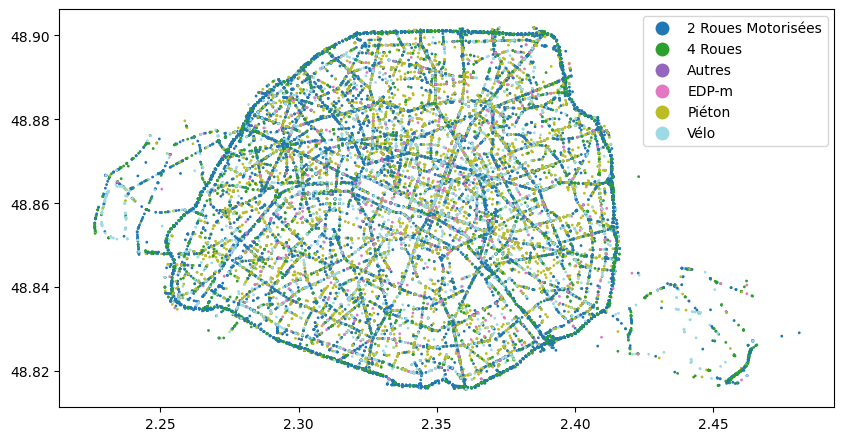

In [62]:
Accidents.plot(figsize=(10,12), column = "type", markersize=1, cmap='tab20', legend=True)